**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np

**Load and Inspect Dataset**

In [ ]:
# Reading in data
data=pd.read_excel('../data/TeleCom_Data-1.xlsx')


In [ ]:
#Shape of dataset
print("Shape of dataset:", data.shape)

Shape of dataset: (41180, 21)


In [ ]:
# Show data types
print("Data types of each column:")
print(data.dtypes)

print("Number of numeric columns:", len(data.select_dtypes(include=['int64', 'float64']).columns))
print("Number of categorical columns:", len(data.select_dtypes(include=['object']).columns))

Data types of each column:
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object
Number of numeric columns: 10
Number of categorical columns: 11


In [ ]:
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


**Data Cleaning**

In [ ]:
# Check for duplicate rows

# Count total duplicates (entire row repeated)
duplicates_count = data.duplicated().sum()
print("Total duplicate rows:", duplicates_count)

# Show duplicate rows (if any)
if duplicates_count > 0:
    print("Duplicate rows:")
    print(data[data.duplicated()])
else:
    print("No duplicate rows found.")


Total duplicate rows: 12
Duplicate rows:
       age          job   marital            education  default housing loan  \
1262    39  blue-collar   married             basic.6y       no      no   no   
12257   36      retired   married              unknown       no      no   no   
14230   27   technician    single  professional.course       no      no   no   
16952   47   technician  divorced          high.school       no     yes   no   
18461   32   technician    single  professional.course       no     yes   no   
20212   55     services   married          high.school  unknown      no   no   
20530   41   technician   married  professional.course       no     yes   no   
25213   39       admin.   married    university.degree       no      no   no   
28473   24     services    single          high.school       no     yes   no   
32512   35       admin.   married    university.degree       no     yes   no   
36947   45       admin.   married    university.degree       no      no   no   

In [ ]:
# Remove duplicate rows
data = data.drop_duplicates()

print("New shape after dropping duplicates:", data.shape)


New shape after dropping duplicates: (41168, 21)


In [ ]:
# Drop unnecessary columns
cols_to_drop = ["default", "day_of_week", "pdays", "emp.var.rate", "nr.employed", "duration"]
data = data.drop(columns=[col for col in cols_to_drop if col in data.columns])

print("New shape of dataset:", data.shape)
print("Remaining columns:", data.columns.tolist())


New shape of dataset: (41168, 15)
Remaining columns: ['age', 'job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'campaign', 'previous', 'poutcome', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'y']


In [ ]:
#Check for missing values
print("Missing values:", data.isnull().sum())

Missing values: age               0
job               0
marital           0
education         0
housing           0
loan              0
contact           0
month             0
campaign          0
previous          0
poutcome          0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
y                 0
dtype: int64


In [ ]:
# Replace 'unknown' with NaN in all columns
data = data.replace("unknown", np.nan)

# Re-check missing values
print("Missing values after replacement:\n", data.isnull().sum())

Missing values after replacement:
 age                  0
job                330
marital             80
education         1730
housing            990
loan               990
contact              0
month                0
campaign             0
previous             0
poutcome             0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
y                    0
dtype: int64


In [ ]:
#Handle Missing Values

# Group-based imputation for categorical columns
categorical_cols = ['job', 'education', 'housing', 'loan']

for col in categorical_cols:
    data[col] = data.groupby('marital')[col].transform(lambda x: x.fillna(x.mode()[0]))

# KNN Imputer for numeric columns (only if missing numeric)
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
num_cols = data.select_dtypes(include=['float64', 'int64']).columns
data[num_cols] = imputer.fit_transform(data[num_cols])

# Check if any missing remain
print("Remaining missing values:\n", data.isnull().sum())


Remaining missing values:
 age                0
job               80
marital           80
education         80
housing           80
loan              80
contact            0
month              0
campaign           0
previous           0
poutcome           0
cons.price.idx     0
cons.conf.idx      0
euribor3m          0
y                  0
dtype: int64


In [ ]:
# KNN Imputer for numeric columns (only if missing numeric)
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
num_cols = data.select_dtypes(include=['float64', 'int64']).columns
data[num_cols] = imputer.fit_transform(data[num_cols])


In [ ]:
# Drop remaining rows with missing values (less than 0.2% of dataset)
data.dropna(inplace=True)

In [ ]:
print("Final dataset shape:", data.shape)
print("Missing values remaining:", data.isnull().sum().sum())
data.info()


Final dataset shape: (41088, 15)
Missing values remaining: 0
<class 'pandas.core.frame.DataFrame'>
Index: 41088 entries, 0 to 41179
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41088 non-null  float64
 1   job             41088 non-null  object 
 2   marital         41088 non-null  object 
 3   education       41088 non-null  object 
 4   housing         41088 non-null  object 
 5   loan            41088 non-null  object 
 6   contact         41088 non-null  object 
 7   month           41088 non-null  object 
 8   campaign        41088 non-null  float64
 9   previous        41088 non-null  float64
 10  poutcome        41088 non-null  object 
 11  cons.price.idx  41088 non-null  float64
 12  cons.conf.idx   41088 non-null  float64
 13  euribor3m       41088 non-null  float64
 14  y               41088 non-null  object 
dtypes: float64(6), object(9)
memory usage: 5.0+ MB


**Target Variable Preparation**

In [ ]:
# Rename column 'y' to 'subscribed'
data = data.rename(columns={'y': 'subscribed'})

# Convert 'yes' -> 1, 'no' -> 0
data['subscribed'] = data['subscribed'].map({'yes': 1, 'no': 0})

# Check the result
print(data['subscribed'].value_counts(dropna=False))


subscribed
0    36463
1     4625
Name: count, dtype: int64


In [ ]:
#Target variable distribution (class balance)
print("Target variable distribution (absolute):", data['subscribed'].value_counts())
print("Target variable distribution (percentage):", data['subscribed'].value_counts(normalize=True) * 100)

Target variable distribution (absolute): subscribed
0    36463
1     4625
Name: count, dtype: int64
Target variable distribution (percentage): subscribed
0    88.743672
1    11.256328
Name: proportion, dtype: float64


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


**Encode Categorical Variables**

In [ ]:


# --- Binary Encoding ---
binary_cols = ['housing', 'loan']  # columns with Yes/No values
for col in binary_cols:
    data[col] = data[col].map({'yes': 1, 'no': 0})

# --- Ordinal Encoding ---
# Education has a natural order
education_order = ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
                   'high.school', 'professional.course', 'university.degree']
data['education'] = data['education'].replace('unknown', np.nan)
data['education'] = data['education'].fillna('basic.9y')
data['education'] = data['education'].astype(pd.CategoricalDtype(categories=education_order, ordered=True))
data['education'] = data['education'].cat.codes  # converts ordered categories into 0–n codes

# --- Define columns for One-Hot Encoding ---
onehot_cols = ['job', 'marital', 'contact', 'month', 'poutcome']

# --- Numeric columns (keep automatically detected numeric ones) ---
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['subscribed']]  # exclude target

# --- Define OneHotEncoder transformer ---
onehot_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# --- Combine in ColumnTransformer ---
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('onehot', onehot_transformer, onehot_cols)
    ],
    remainder='passthrough'  # keeps binary/ordinal columns as they are
)


**Define Features and Target**

In [ ]:
X = data.drop('subscribed', axis=1)
y = data['subscribed']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (41088, 14)
Shape of y: (41088,)


**Train-Test Split**

In [ ]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (32870, 14)
Testing set shape: (8218, 14)


**Feature Scaling**

In [ ]:
# Feature Scaling Setup (for numeric variables only)
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify numeric and categorical columns again
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['subscribed']]  # exclude target

categorical_cols = ['job', 'marital', 'contact', 'month', 'poutcome']  # for one-hot encoding
binary_cols = ['housing', 'loan']  # already mapped to 0/1
ordinal_cols = ['education']  # already ordinal encoded

# Define transformers
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine all transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='passthrough'  # keeps binary and ordinal columns as they are
)

# Verify pipeline
print("Feature scaling and encoding pipeline defined successfully.")

Feature scaling and encoding pipeline defined successfully.


**Parametric Model: Logistic Regression**

In [ ]:

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns


**Build Logistic Regression Pipeline**

In [ ]:

# PARAMETRIC MODEL — LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression

# Build full modeling pipeline
logreg_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42))
])

# Train model
logreg_model.fit(X_train, y_train)
print("Logistic Regression model trained successfully.")


Logistic Regression model trained successfully.


**Make Predictions**

In [ ]:
# Predict on test set
y_pred_lr = logreg_model.predict(X_test)
y_prob_lr = logreg_model.predict_proba(X_test)[:, 1]


**Evaluate the Model**

In [ ]:
# MODEL EVALUATION FUNCTION
def evaluate_model(model, X_test, y_test, model_name="Model"):
    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities (for ROC/AUC) – handle models without predict_proba
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_test)
        # convert arbitrary scores to [0,1] for AUC
        smin, smax = scores.min(), scores.max()
        y_prob = (scores - smin) / (smax - smin + 1e-9)
    else:
        # fallback (rare) – AUC will not be meaningful, but no crash
        y_prob = np.zeros_like(y_pred, dtype=float)

    # Metrics (zero_division=0 avoids warnings on minority class)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_prob)

    # Print summary
    print(f"{model_name} PERFORMANCE")
    print(f"Accuracy:  {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall:    {rec:.3f}")
    print(f"F1 Score:  {f1:.3f}")
    print(f"ROC-AUC:   {auc:.3f}")
    print("\nClassification Report:\n",
          classification_report(y_test, y_pred, digits=3))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"{model_name} — Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc:.2f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.title(f"{model_name} — ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Return metrics for later comparison if needed
    return {"model": model_name, "accuracy": acc, "precision": prec,
            "recall": rec, "f1": f1, "roc_auc": auc}


Logistic Regression PERFORMANCE
Accuracy:  0.826
Precision: 0.351
Recall:    0.644
F1 Score:  0.454
ROC-AUC:   0.799

Classification Report:
               precision    recall  f1-score   support

           0      0.950     0.849     0.896      7293
           1      0.351     0.644     0.454       925

    accuracy                          0.826      8218
   macro avg      0.650     0.746     0.675      8218
weighted avg      0.882     0.826     0.846      8218



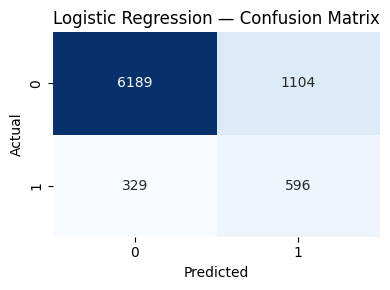

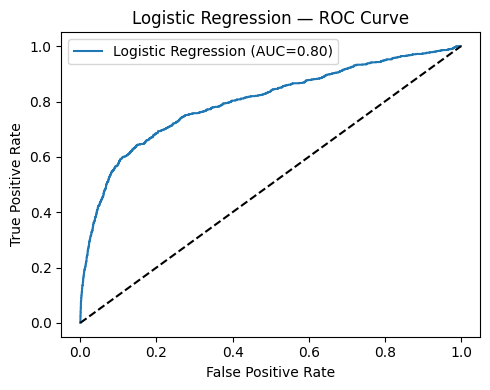

{'model': 'Logistic Regression',
 'accuracy': 0.8256266731564857,
 'precision': 0.35058823529411764,
 'recall': 0.6443243243243243,
 'f1': 0.4540952380952381,
 'roc_auc': np.float64(0.7991096238155062)}

In [ ]:

log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
log_reg_pipeline.fit(X_train, y_train)
evaluate_model(log_reg_pipeline, X_test, y_test, model_name="Logistic Regression")


**Interpret Coefficients (Find Key Predictors)**

Top positive predictors (increase chance of subscription):


,Feature,Coefficient
29,cat__month_mar,1.107625
36,cat__poutcome_success,1.021461
32,cat__month_oct,0.461746
13,cat__job_retired,0.341750
5,num__cons.price.idx,0.262547
26,cat__month_dec,0.257259
16,cat__job_student,0.255630
6,num__cons.conf.idx,0.243340
22,cat__contact_cellular,0.221066
10,cat__job_entrepreneur,0.063330



Top negative predictors (reduce chance of subscription):


,Feature,Coefficient
15,cat__job_services,-0.143932
23,cat__contact_telephone,-0.217193
11,cat__job_housemaid,-0.226219
31,cat__month_nov,-0.249785
35,cat__poutcome_nonexistent,-0.253462
33,cat__month_sep,-0.256360
25,cat__month_aug,-0.304227
34,cat__poutcome_failure,-0.764126
30,cat__month_may,-0.801998
7,num__euribor3m,-0.927589


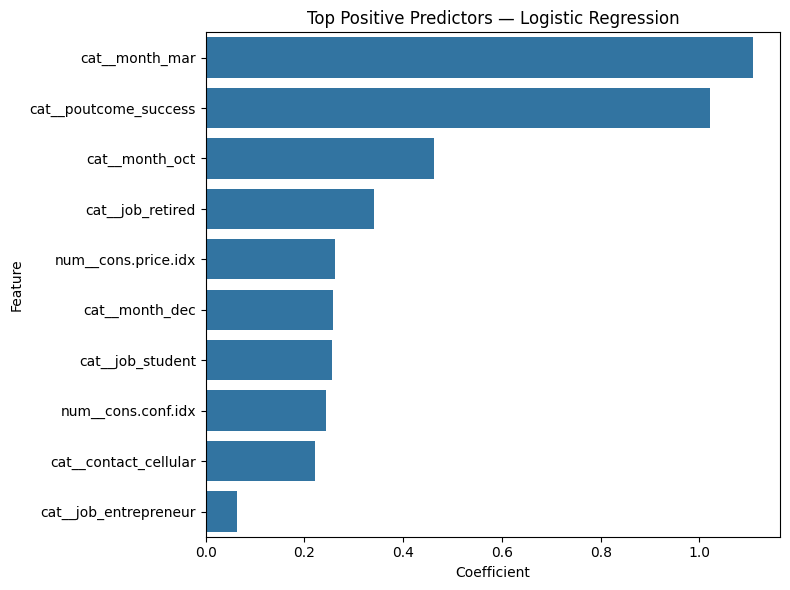

In [ ]:

#INTERPRETATION : COEFFICIENTS

import matplotlib.pyplot as plt
import seaborn as sns

# 1) Get feature names directly from the ColumnTransformer
pre = logreg_model.named_steps['preprocessor']

try:
    # This returns names like 'num__age', 'cat__job_admin', etc.
    feature_names = pre.get_feature_names_out()
except Exception as e:
    print("Could not get feature names from ColumnTransformer:", e)
    # Fallback: use a simple index as names to avoid a crash
    n_features = logreg_model.named_steps['classifier'].coef_.shape[1]
    feature_names = np.array([f"feature_{i}" for i in range(n_features)])

# 2) Get coefficients from the trained Logistic Regression
coef = logreg_model.named_steps['classifier'].coef_.ravel()

# 3) Sanity check & align lengths if needed
if len(feature_names) != len(coef):
    print(f"Warning: name/coef length mismatch: {len(feature_names)} vs {len(coef)}. Aligning to min length.")
    m = min(len(feature_names), len(coef))
    feature_names = feature_names[:m]
    coef = coef[:m]

# 4) Build, sort, and display table
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coef}) \
            .sort_values('Coefficient', ascending=False)

print("Top positive predictors (increase chance of subscription):")
display(coef_df.head(10))

print("\nTop negative predictors (reduce chance of subscription):")
display(coef_df.tail(10))

# 5) Optional plot of top positives
plt.figure(figsize=(8,6))
sns.barplot(data=coef_df.head(10), x='Coefficient', y='Feature')
plt.title("Top Positive Predictors — Logistic Regression")
plt.tight_layout(); plt.show()


**Cross-validation**

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Use your actual model variable name here (logreg_model or log_reg_pipeline)
lr_cv_auc = cross_val_score(logreg_model, X_train, y_train, cv=cv,
                            scoring="roc_auc", n_jobs=-1)

print(f"Logistic Regression – CV ROC-AUC: mean={lr_cv_auc.mean():.3f} ± {lr_cv_auc.std():.3f}")


Logistic Regression – CV ROC-AUC: mean=0.788 ± 0.007


**Non-Parametric Model: Random Forest**

**Train the Random Forest model**

In [ ]:

# NON-PARAMETRIC MODEL : RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier

# Build pipeline using the same preprocessor
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,              # number of trees
        max_depth=None,                # grow until pure
        min_samples_split=2,
        class_weight='balanced',       # handle class imbalance
        random_state=42,
        n_jobs=-1                      # use all CPU cores
    ))
])

# Train model
rf_model.fit(X_train, y_train)
print("Random Forest model trained successfully.")


Random Forest model trained successfully.


**Make predictions**

In [ ]:
# Predict on test data
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]


**Evaluate Performance**

Random Forest PERFORMANCE
Accuracy:  0.893
Precision: 0.549
Recall:    0.272
F1 Score:  0.364
ROC-AUC:   0.781

Detailed classification report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7293
           1       0.55      0.27      0.36       925

    accuracy                           0.89      8218
   macro avg       0.73      0.62      0.65      8218
weighted avg       0.87      0.89      0.88      8218



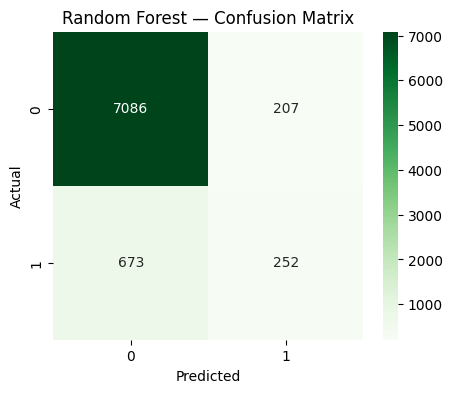

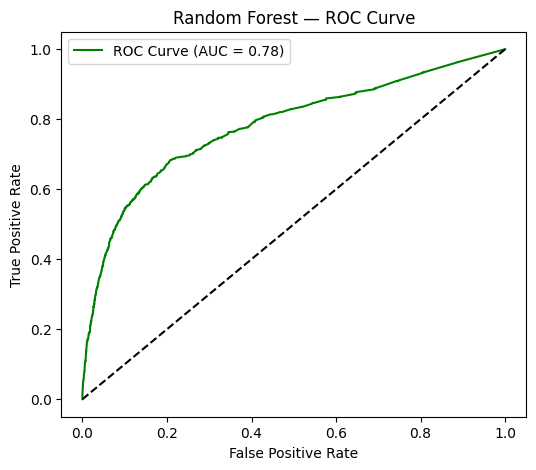

In [ ]:

# MODEL EVALUATION FUNCTION

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve,
                             classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

acc  = accuracy_score(y_test, y_pred_rf)
prec = precision_score(y_test, y_pred_rf)
rec  = recall_score(y_test, y_pred_rf)
f1   = f1_score(y_test, y_pred_rf)
auc  = roc_auc_score(y_test, y_prob_rf)

print(f"Random Forest PERFORMANCE")
print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1 Score:  {f1:.3f}")
print(f"ROC-AUC:   {auc:.3f}")

print("\nDetailed classification report:")
print(classification_report(y_test, y_pred_rf))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest — Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.2f})', color='green')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Random Forest — ROC Curve")
plt.legend(); plt.show()


**Feature importance analysis**

Top important features:


,Feature,Importance
7,num__euribor3m,0.224077
0,num__age,0.192691
3,num__campaign,0.095338
37,remainder__education,0.070996
6,num__cons.conf.idx,0.049074
5,num__cons.price.idx,0.038034
1,num__housing,0.034349
36,cat__poutcome_success,0.028129
2,num__loan,0.023175
4,num__previous,0.016487


/tmp/ipython-input-532266544.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp.head(15), x='Importance', y='Feature', palette='Greens_r')


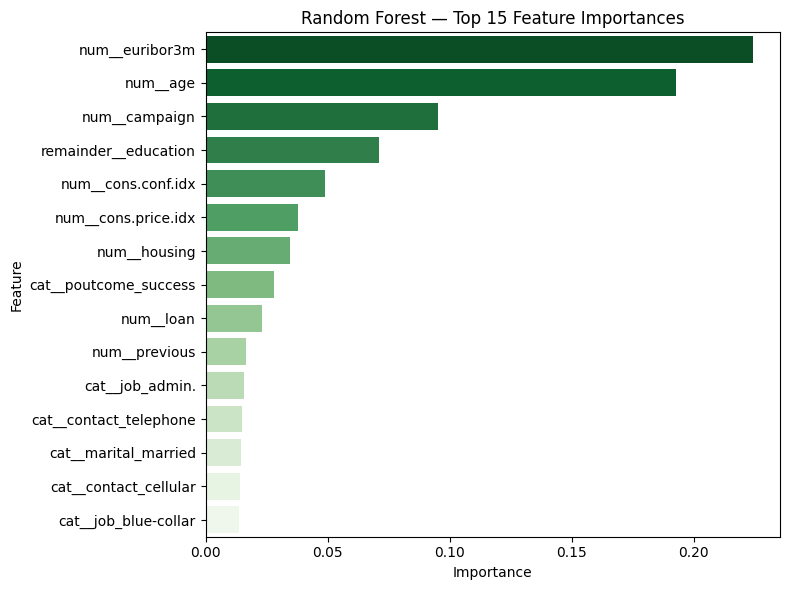

In [ ]:

# FEATURE IMPORTANCE

# Get feature names directly from preprocessor
pre = rf_model.named_steps['preprocessor']
feature_names = pre.get_feature_names_out()

# Retrieve feature importances from Random Forest
importances = rf_model.named_steps['classifier'].feature_importances_

feat_imp = (pd.DataFrame({'Feature': feature_names, 'Importance': importances})
              .sort_values('Importance', ascending=False))

print("Top important features:")
display(feat_imp.head(15))

# Plot
plt.figure(figsize=(8,6))
sns.barplot(data=feat_imp.head(15), x='Importance', y='Feature', palette='Greens_r')
plt.title("Random Forest — Top 15 Feature Importances")
plt.tight_layout(); plt.show()


**Cross Validation**

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_cv_auc = cross_val_score(rf_model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"Random Forest 5-fold ROC-AUC : mean = {rf_cv_auc.mean():.3f} ± {rf_cv_auc.std():.3f}")


Random Forest 5-fold ROC-AUC : mean = 0.770 ± 0.005


**Model Comparison**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Define helper function to get metrics quickly
def get_metrics(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

# Get metrics for both models
logreg_results = get_metrics(logreg_model, X_test, y_test)
rf_results = get_metrics(rf_model, X_test, y_test)

# Combine into comparison DataFrame
comparison_df = pd.DataFrame({
    "Metric": logreg_results.keys(),
    "Logistic Regression": logreg_results.values(),
    "Random Forest": rf_results.values()
})

# Display neatly
comparison_df = comparison_df.round(3)
display(comparison_df)


,Metric,Logistic Regression,Random Forest
0,Accuracy,0.826,0.893
1,Precision,0.351,0.549
2,Recall,0.644,0.272
3,F1 Score,0.454,0.364
4,ROC-AUC,0.799,0.781


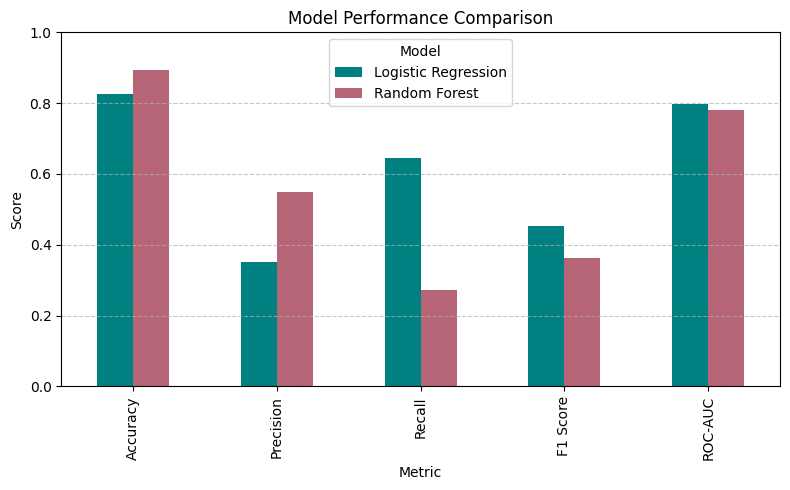

In [ ]:
import matplotlib.pyplot as plt

comparison_df.set_index("Metric").plot(kind="bar", figsize=(8,5), color=["#008080", "#b56576"])
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(title="Model")
plt.tight_layout()
plt.show()


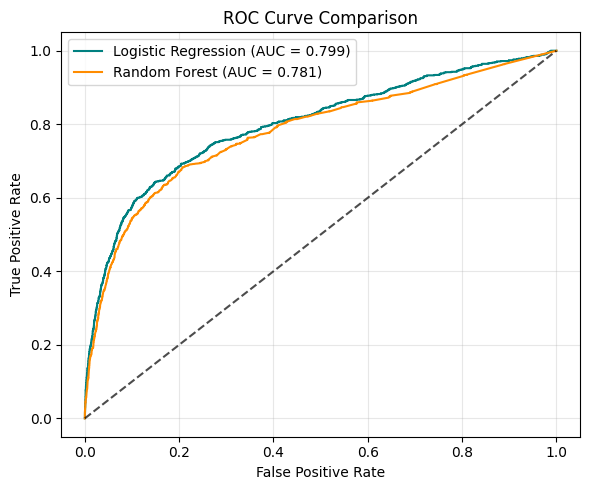

In [ ]:
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities
y_prob_lr = logreg_model.predict_proba(X_test)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Compute ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# Compute AUC scores
auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)

# Plot ROC comparison
plt.figure(figsize=(6, 5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})", color='teal')
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})", color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.7)
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
